In [1]:
# Validate size normalization and rigid egocentric keypoints directly from source HDF5 files.
from pathlib import Path
import json

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATAVERSE_ROOT = Path('/Users/meganbishop/moseq_dataverse')
KEYPOINT_ROOT = DATAVERSE_ROOT / 'keypoint_moseq'
SOURCE_ROOT = DATAVERSE_ROOT / 'data_files'
MANIFEST_PATH = KEYPOINT_ROOT / 'manifest_by_species.csv'
METADATA_PATH = KEYPOINT_ROOT / 'metadata.json'
OUTPUT_DIR = Path('/Users/meganbishop/slowmodeevo/outputs/keypoint_validation')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Fixed validation defaults; all species are included automatically.
RECORDINGS_PER_SPECIES = 3
MAX_FRAMES_PER_RECORDING = 40000
FRAME_STRIDE = 40
MIN_CONFIDENCE = 0.5

DATASETS = {
    'gimbal': 'recording/gimbal',
    'size_normalized_gimbal': 'recording/size_normalized_gimbal_keypoints',
    'egocentric_rigid': 'recording/egocentric_coordinates_rigid',
    'egocentric_rigid_no_sizenorm': 'recording/egocentric_coordinates_rigid_no_sizenorm',
    'confidence': 'recording/confidences_3d',
}

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 240,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


In [2]:
# Load the species manifest and shared keypoint metadata.
manifest = pd.read_csv(MANIFEST_PATH)
manifest = manifest[manifest['status'].isin(['ok', 'exists'])].copy()
manifest['subject'] = manifest['subject'].astype(str)
manifest = manifest.sort_values(['species_folder', 'subject', 'recording_id'])

with open(METADATA_PATH) as f:
    metadata = json.load(f)

bodyparts = list(metadata['bodyparts'])
bodypart_index = {name: i for i, name in enumerate(bodyparts)}
species = sorted(manifest['species_folder'].dropna().unique())

SKELETAL_PAIRS = {
    'nose_to_tail_base': ('nose_tip', 'tail_base'),
    'forehead_to_tail_base': ('forehead', 'tail_base'),
    'spine_high_to_spine_low': ('spine_high', 'spine_low'),
    'shoulder_width': ('left_shoulder', 'right_shoulder'),
    'hind_paw_width': ('left_hind_paw_front', 'right_hind_paw_front'),
}

selected_manifest = (
    manifest.groupby('species_folder', sort=True, group_keys=False)
    .head(RECORDINGS_PER_SPECIES)
    .reset_index(drop=True)
)

print('species:', species)
print('selected recordings:', len(selected_manifest))
print('bodyparts:', len(bodyparts))


species: ['Mus_caroli', 'Mus_musculus', 'Mus_spretus', 'Peromyscus_californicus', 'Peromyscus_gossypinus', 'Peromyscus_leucopus', 'Peromyscus_maniculatus', 'Peromyscus_polionotus']
selected recordings: 24
bodyparts: 25


In [3]:
# Helpers for confidence-filtered skeletal distances and orientation concentration.
def source_path(row):
    return SOURCE_ROOT / f"{row['recording_id']}.hdf5"


def pair_distance(coordinates, confidence, left_name, right_name):
    left = bodypart_index[left_name]
    right = bodypart_index[right_name]
    valid = (
        (confidence[:, left] >= MIN_CONFIDENCE)
        & (confidence[:, right] >= MIN_CONFIDENCE)
        & np.isfinite(coordinates[:, left]).all(axis=1)
        & np.isfinite(coordinates[:, right]).all(axis=1)
    )
    distance = np.linalg.norm(coordinates[:, left] - coordinates[:, right], axis=1)
    return np.where(valid, distance, np.nan)


def orientation_concentration(coordinates, confidence):
    low = bodypart_index['spine_low']
    high = bodypart_index['spine_high']
    valid = (
        (confidence[:, low] >= MIN_CONFIDENCE)
        & (confidence[:, high] >= MIN_CONFIDENCE)
        & np.isfinite(coordinates[:, low]).all(axis=1)
        & np.isfinite(coordinates[:, high]).all(axis=1)
    )
    vectors = coordinates[:, high] - coordinates[:, low]
    norms = np.linalg.norm(vectors, axis=1)
    valid &= norms > 1e-8
    unit = vectors[valid] / norms[valid, None]
    if not len(unit):
        return np.nan, np.full(3, np.nan)
    mean_vector = unit.mean(axis=0)
    return float(np.linalg.norm(mean_vector)), mean_vector


def all_pair_distance_error(reference, transformed, confidence):
    left, right = np.triu_indices(len(bodyparts), 1)
    valid_keypoints = confidence >= MIN_CONFIDENCE
    valid_pairs = valid_keypoints[:, left] & valid_keypoints[:, right]
    reference_distance = np.linalg.norm(reference[:, left] - reference[:, right], axis=2)
    transformed_distance = np.linalg.norm(transformed[:, left] - transformed[:, right], axis=2)
    relative_error = np.abs(reference_distance - transformed_distance) / np.maximum(reference_distance, 1e-8)
    relative_error = np.where(valid_pairs, relative_error, np.nan)
    return float(np.nanmedian(relative_error)), float(np.nanmax(relative_error))


def savefig(fig, name):
    fig.savefig(OUTPUT_DIR / f'{name}.png', bbox_inches='tight')
    fig.savefig(OUTPUT_DIR / f'{name}.pdf', bbox_inches='tight')
    return fig


In [4]:
# Compute matched metrics from normalized, unnormalized, gimbal, and rigid-egocentric source arrays.
metric_rows = []
orientation_rows = []
invariance_rows = []

for row_number, row in selected_manifest.iterrows():
    path = source_path(row)
    with h5py.File(path, 'r') as f:
        missing = [dataset for dataset in DATASETS.values() if dataset not in f]
        if missing:
            raise KeyError(f'{path}: missing datasets {missing}')
        stop = min(MAX_FRAMES_PER_RECORDING, *(f[dataset].shape[0] for dataset in DATASETS.values()))
        frame_index = np.arange(0, stop, FRAME_STRIDE, dtype=int)
        arrays = {
            name: np.asarray(f[dataset][frame_index], dtype=np.float32)
            for name, dataset in DATASETS.items()
            if name != 'confidence'
        }
        confidence = np.asarray(f[DATASETS['confidence']][frame_index], dtype=np.float32)
        descriptions = {
            name: str(f[dataset].attrs.get('description', ''))
            for name, dataset in DATASETS.items()
            if name != 'confidence'
        }

    base = {
        'species': row['species_folder'],
        'subject': str(row['subject']),
        'recording_id': str(row['recording_id']),
        'source_path': str(path),
        'n_sampled_frames': len(frame_index),
    }

    for metric_name, pair in SKELETAL_PAIRS.items():
        for representation in ['egocentric_rigid_no_sizenorm', 'egocentric_rigid']:
            distances = pair_distance(arrays[representation], confidence, *pair)
            metric_rows.append({
                **base,
                'representation': representation,
                'metric': metric_name,
                'median_distance': float(np.nanmedian(distances)),
                'valid_frames': int(np.isfinite(distances).sum()),
            })

    for representation in ['gimbal', 'size_normalized_gimbal', 'egocentric_rigid_no_sizenorm', 'egocentric_rigid']:
        concentration, mean_direction = orientation_concentration(arrays[representation], confidence)
        orientation_rows.append({
            **base,
            'representation': representation,
            'orientation_concentration': concentration,
            'mean_direction_x': mean_direction[0],
            'mean_direction_y': mean_direction[1],
            'mean_direction_z': mean_direction[2],
            'description': descriptions[representation],
        })

    median_error, max_error = all_pair_distance_error(
        arrays['size_normalized_gimbal'], arrays['egocentric_rigid'], confidence
    )
    invariance_rows.append({
        **base,
        'median_relative_distance_error': median_error,
        'max_relative_distance_error': max_error,
        'normalized_description': descriptions['size_normalized_gimbal'],
        'egocentric_description': descriptions['egocentric_rigid'],
    })

metric_df = pd.DataFrame(metric_rows)
orientation_df = pd.DataFrame(orientation_rows)
invariance_df = pd.DataFrame(invariance_rows)

metric_df.to_csv(OUTPUT_DIR / 'skeletal_distance_metrics.csv', index=False)
orientation_df.to_csv(OUTPUT_DIR / 'orientation_metrics.csv', index=False)
invariance_df.to_csv(OUTPUT_DIR / 'rigid_distance_invariance.csv', index=False)

metric_df.head()


,species,subject,recording_id,source_path,n_sampled_frames,representation,metric,median_distance,valid_frames
0,Mus_caroli,CAROLI-F-2L-741,24-11-20-13-48-38-086920,/Users/meganbishop/moseq_dataverse/data_files/...,1000,egocentric_rigid_no_sizenorm,nose_to_tail_base,58.727497,983
1,Mus_caroli,CAROLI-F-2L-741,24-11-20-13-48-38-086920,/Users/meganbishop/moseq_dataverse/data_files/...,1000,egocentric_rigid,nose_to_tail_base,76.068474,983
2,Mus_caroli,CAROLI-F-2L-741,24-11-20-13-48-38-086920,/Users/meganbishop/moseq_dataverse/data_files/...,1000,egocentric_rigid_no_sizenorm,forehead_to_tail_base,49.139858,983
3,Mus_caroli,CAROLI-F-2L-741,24-11-20-13-48-38-086920,/Users/meganbishop/moseq_dataverse/data_files/...,1000,egocentric_rigid,forehead_to_tail_base,64.974358,983
4,Mus_caroli,CAROLI-F-2L-741,24-11-20-13-48-38-086920,/Users/meganbishop/moseq_dataverse/data_files/...,1000,egocentric_rigid_no_sizenorm,spine_high_to_spine_low,27.051006,976


In [5]:
# Summarize whether normalization reduces cross-species size variation and acts as uniform scaling.
recording_metrics = metric_df.pivot_table(
    index=['species', 'subject', 'recording_id', 'metric'],
    columns='representation',
    values='median_distance',
).reset_index()
recording_metrics['normalization_scale_ratio'] = (
    recording_metrics['egocentric_rigid']
    / recording_metrics['egocentric_rigid_no_sizenorm']
)

species_medians = (
    metric_df.groupby(['representation', 'species', 'metric'], as_index=False)['median_distance']
    .median()
)
range_table = species_medians.pivot_table(
    index='metric', columns='representation', values='median_distance', aggfunc=lambda x: x.max() / x.min()
)
range_table['variation_reduction_fraction'] = 1.0 - (
    range_table['egocentric_rigid'] / range_table['egocentric_rigid_no_sizenorm']
)

scale_uniformity = (
    recording_metrics.groupby(['species', 'subject', 'recording_id'])['normalization_scale_ratio']
    .agg(['mean', 'std'])
    .reset_index()
)
scale_uniformity['scale_ratio_cv'] = scale_uniformity['std'] / scale_uniformity['mean'].abs()

validation_results = pd.DataFrame([
    {
        'test': 'source metadata identifies rigid egocentric coordinates after size normalization',
        'value': float(orientation_df.loc[orientation_df['representation'].eq('egocentric_rigid'), 'description'].str.lower().str.contains('rigid').all()
                       and orientation_df.loc[orientation_df['representation'].eq('egocentric_rigid'), 'description'].str.lower().str.contains('size normalization').all()),
        'threshold': 1.0,
        'pass': bool(orientation_df.loc[orientation_df['representation'].eq('egocentric_rigid'), 'description'].str.lower().str.contains('rigid').all()
                     and orientation_df.loc[orientation_df['representation'].eq('egocentric_rigid'), 'description'].str.lower().str.contains('size normalization').all()),
    },
    {
        'test': 'rigid transform preserves normalized all-pair distances',
        'value': float(invariance_df['max_relative_distance_error'].max()),
        'threshold': 1e-4,
        'pass': bool(invariance_df['max_relative_distance_error'].max() < 1e-4),
    },
    {
        'test': 'normalization scale effect is broadly consistent across skeletal measures',
        'value': float(scale_uniformity['scale_ratio_cv'].median()),
        'threshold': 0.12,
        'pass': bool(scale_uniformity['scale_ratio_cv'].median() < 0.12),
    },
    {
        'test': 'normalization reduces mean cross-species skeletal-size range',
        'value': float(range_table['variation_reduction_fraction'].mean()),
        'threshold': 0.0,
        'pass': bool(range_table['variation_reduction_fraction'].mean() > 0.0),
    },
    {
        'test': 'rigid egocentric coordinates improve spine orientation concentration',
        'value': float(
            orientation_df.loc[orientation_df['representation'].eq('egocentric_rigid'), 'orientation_concentration'].median()
            - orientation_df.loc[orientation_df['representation'].eq('size_normalized_gimbal'), 'orientation_concentration'].median()
        ),
        'threshold': 0.0,
        'pass': bool(
            orientation_df.loc[orientation_df['representation'].eq('egocentric_rigid'), 'orientation_concentration'].median()
            > orientation_df.loc[orientation_df['representation'].eq('size_normalized_gimbal'), 'orientation_concentration'].median()
        ),
    },
])

range_table.to_csv(OUTPUT_DIR / 'cross_species_size_ranges.csv')
scale_uniformity.to_csv(OUTPUT_DIR / 'normalization_scale_uniformity.csv', index=False)
validation_results.to_csv(OUTPUT_DIR / 'validation_results.csv', index=False)

display(range_table.round(4))
display(scale_uniformity.groupby('species')['scale_ratio_cv'].median().round(4))
display(validation_results)


representation,egocentric_rigid,egocentric_rigid_no_sizenorm,variation_reduction_fraction
metric,,,
forehead_to_tail_base,1.0811,1.4377,0.2480
hind_paw_width,1.1391,1.7441,0.3468
nose_to_tail_base,1.1072,1.4454,0.2340
shoulder_width,1.1679,1.9098,0.3884
spine_high_to_spine_low,1.0625,1.5288,0.3050


species
Mus_caroli                 0.0390
Mus_musculus               0.0117
Mus_spretus                0.0745
Peromyscus_californicus    0.1075
Peromyscus_gossypinus      0.0454
Peromyscus_leucopus        0.0411
Peromyscus_maniculatus     0.0335
Peromyscus_polionotus      0.0663
Name: scale_ratio_cv, dtype: float64

,test,value,threshold,pass
0,source metadata identifies rigid egocentric co...,1.000000,1.0000,True
1,rigid transform preserves normalized all-pair ...,0.000002,0.0001,True
2,normalization scale effect is broadly consiste...,0.045877,0.1200,True
3,normalization reduces mean cross-species skele...,0.304452,0.0000,True
4,rigid egocentric coordinates improve spine ori...,0.655194,0.0000,True


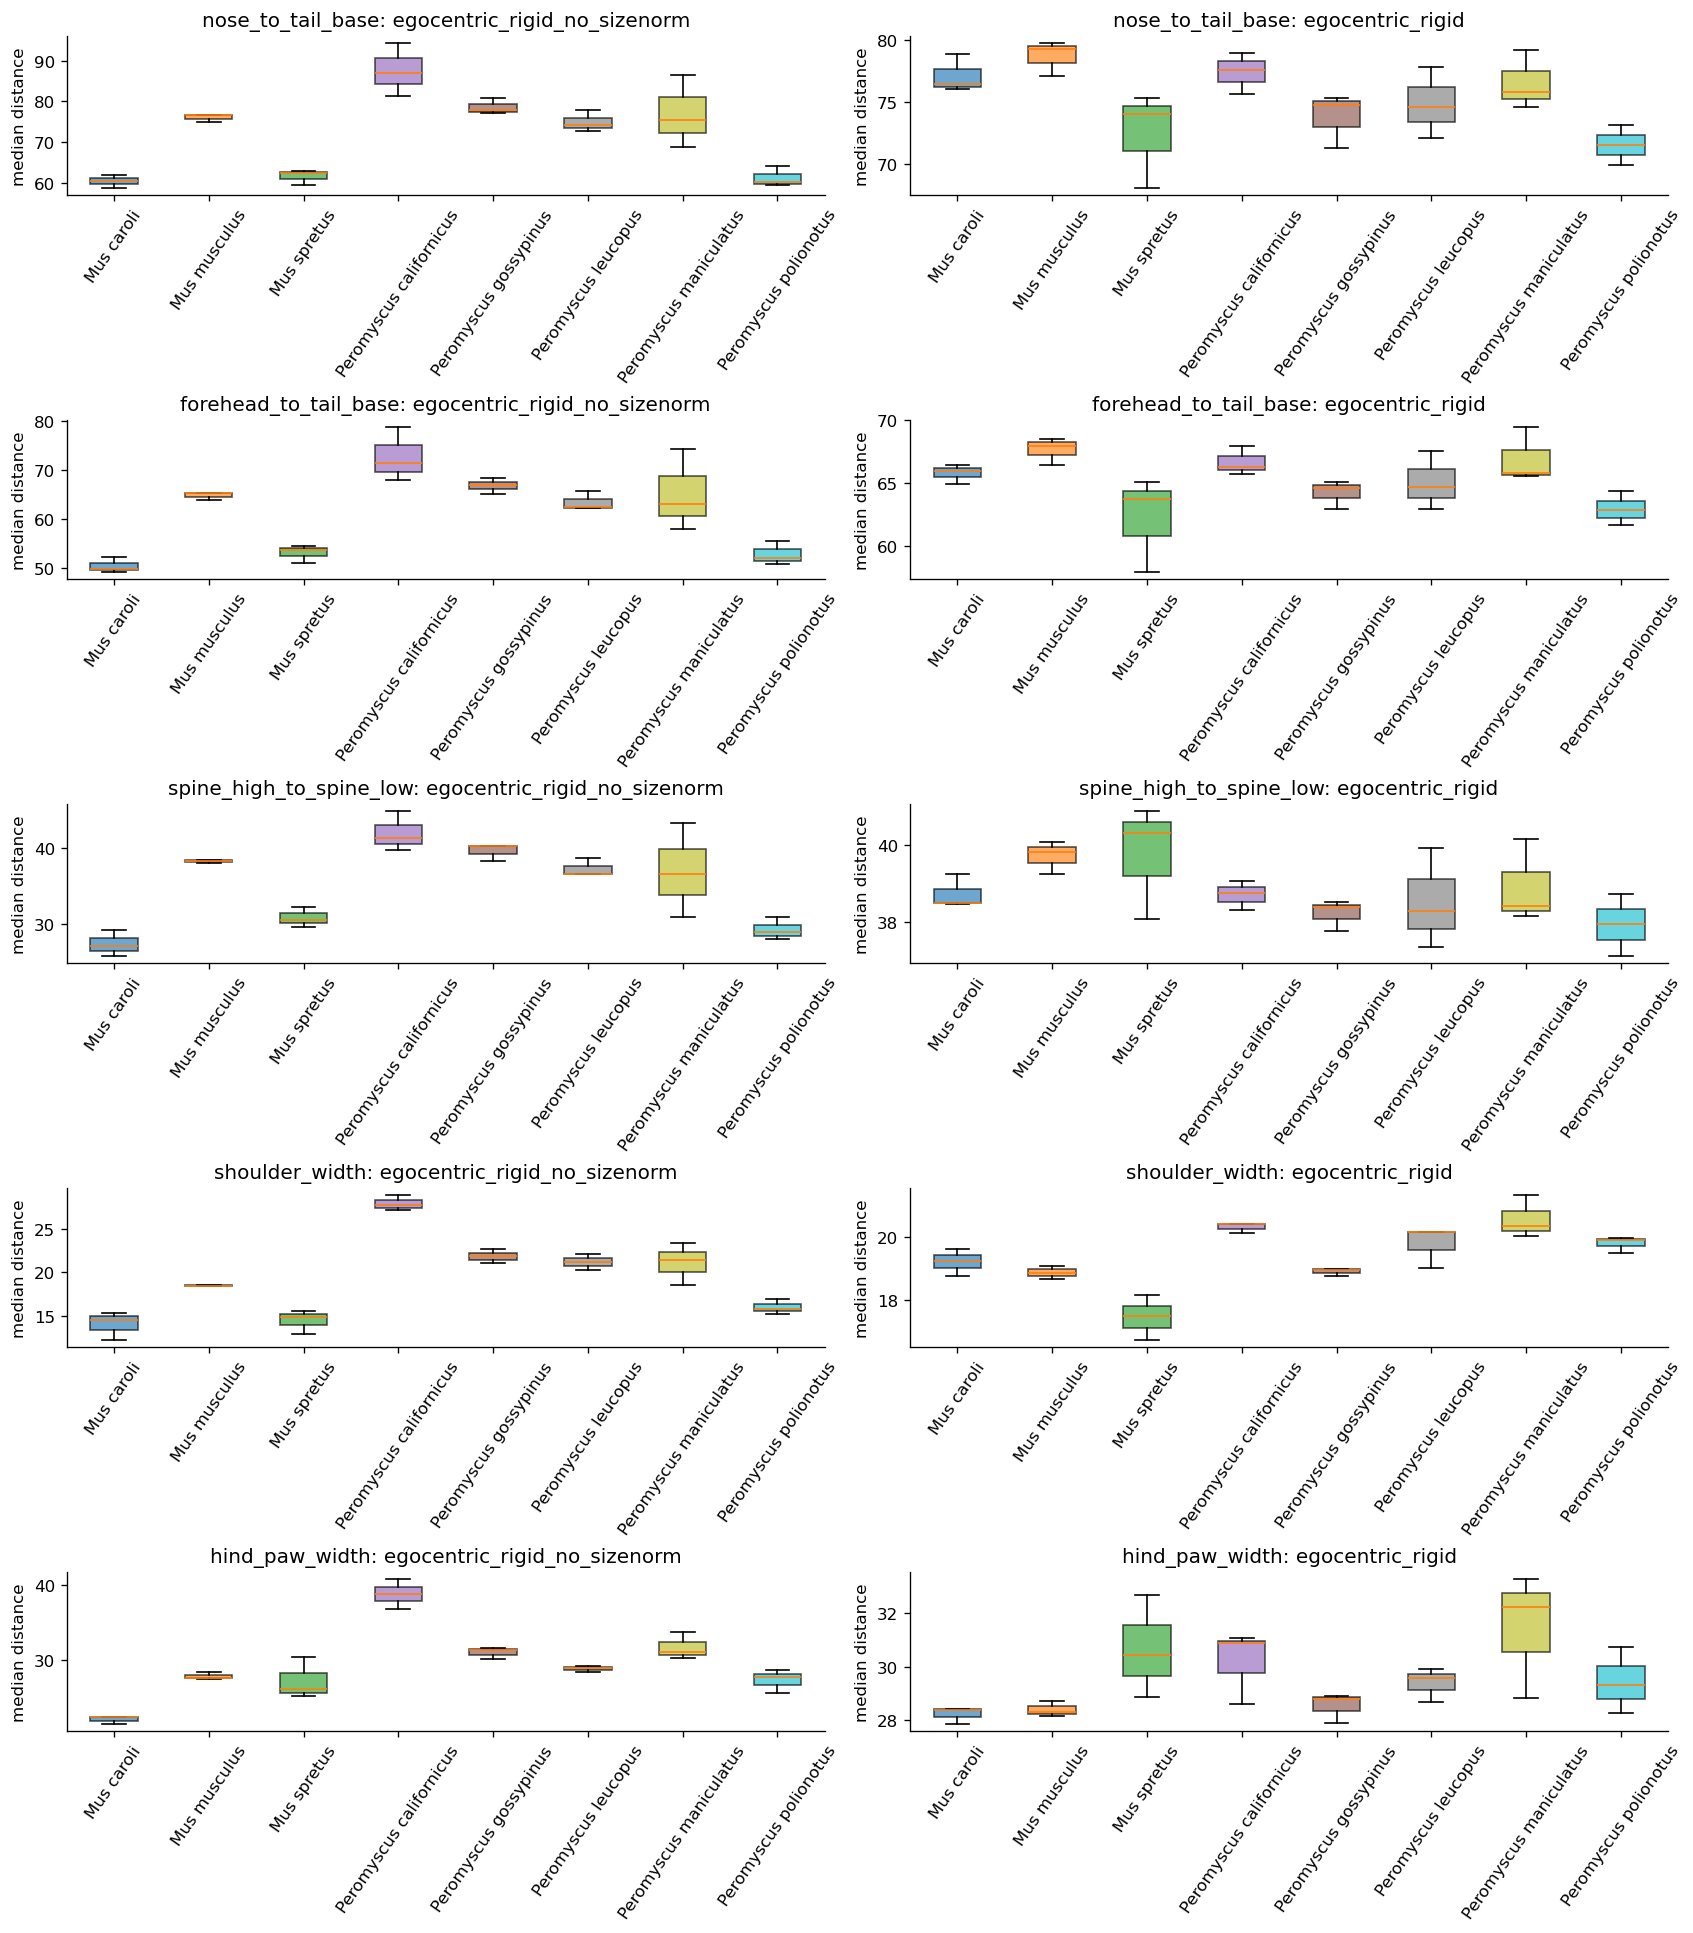

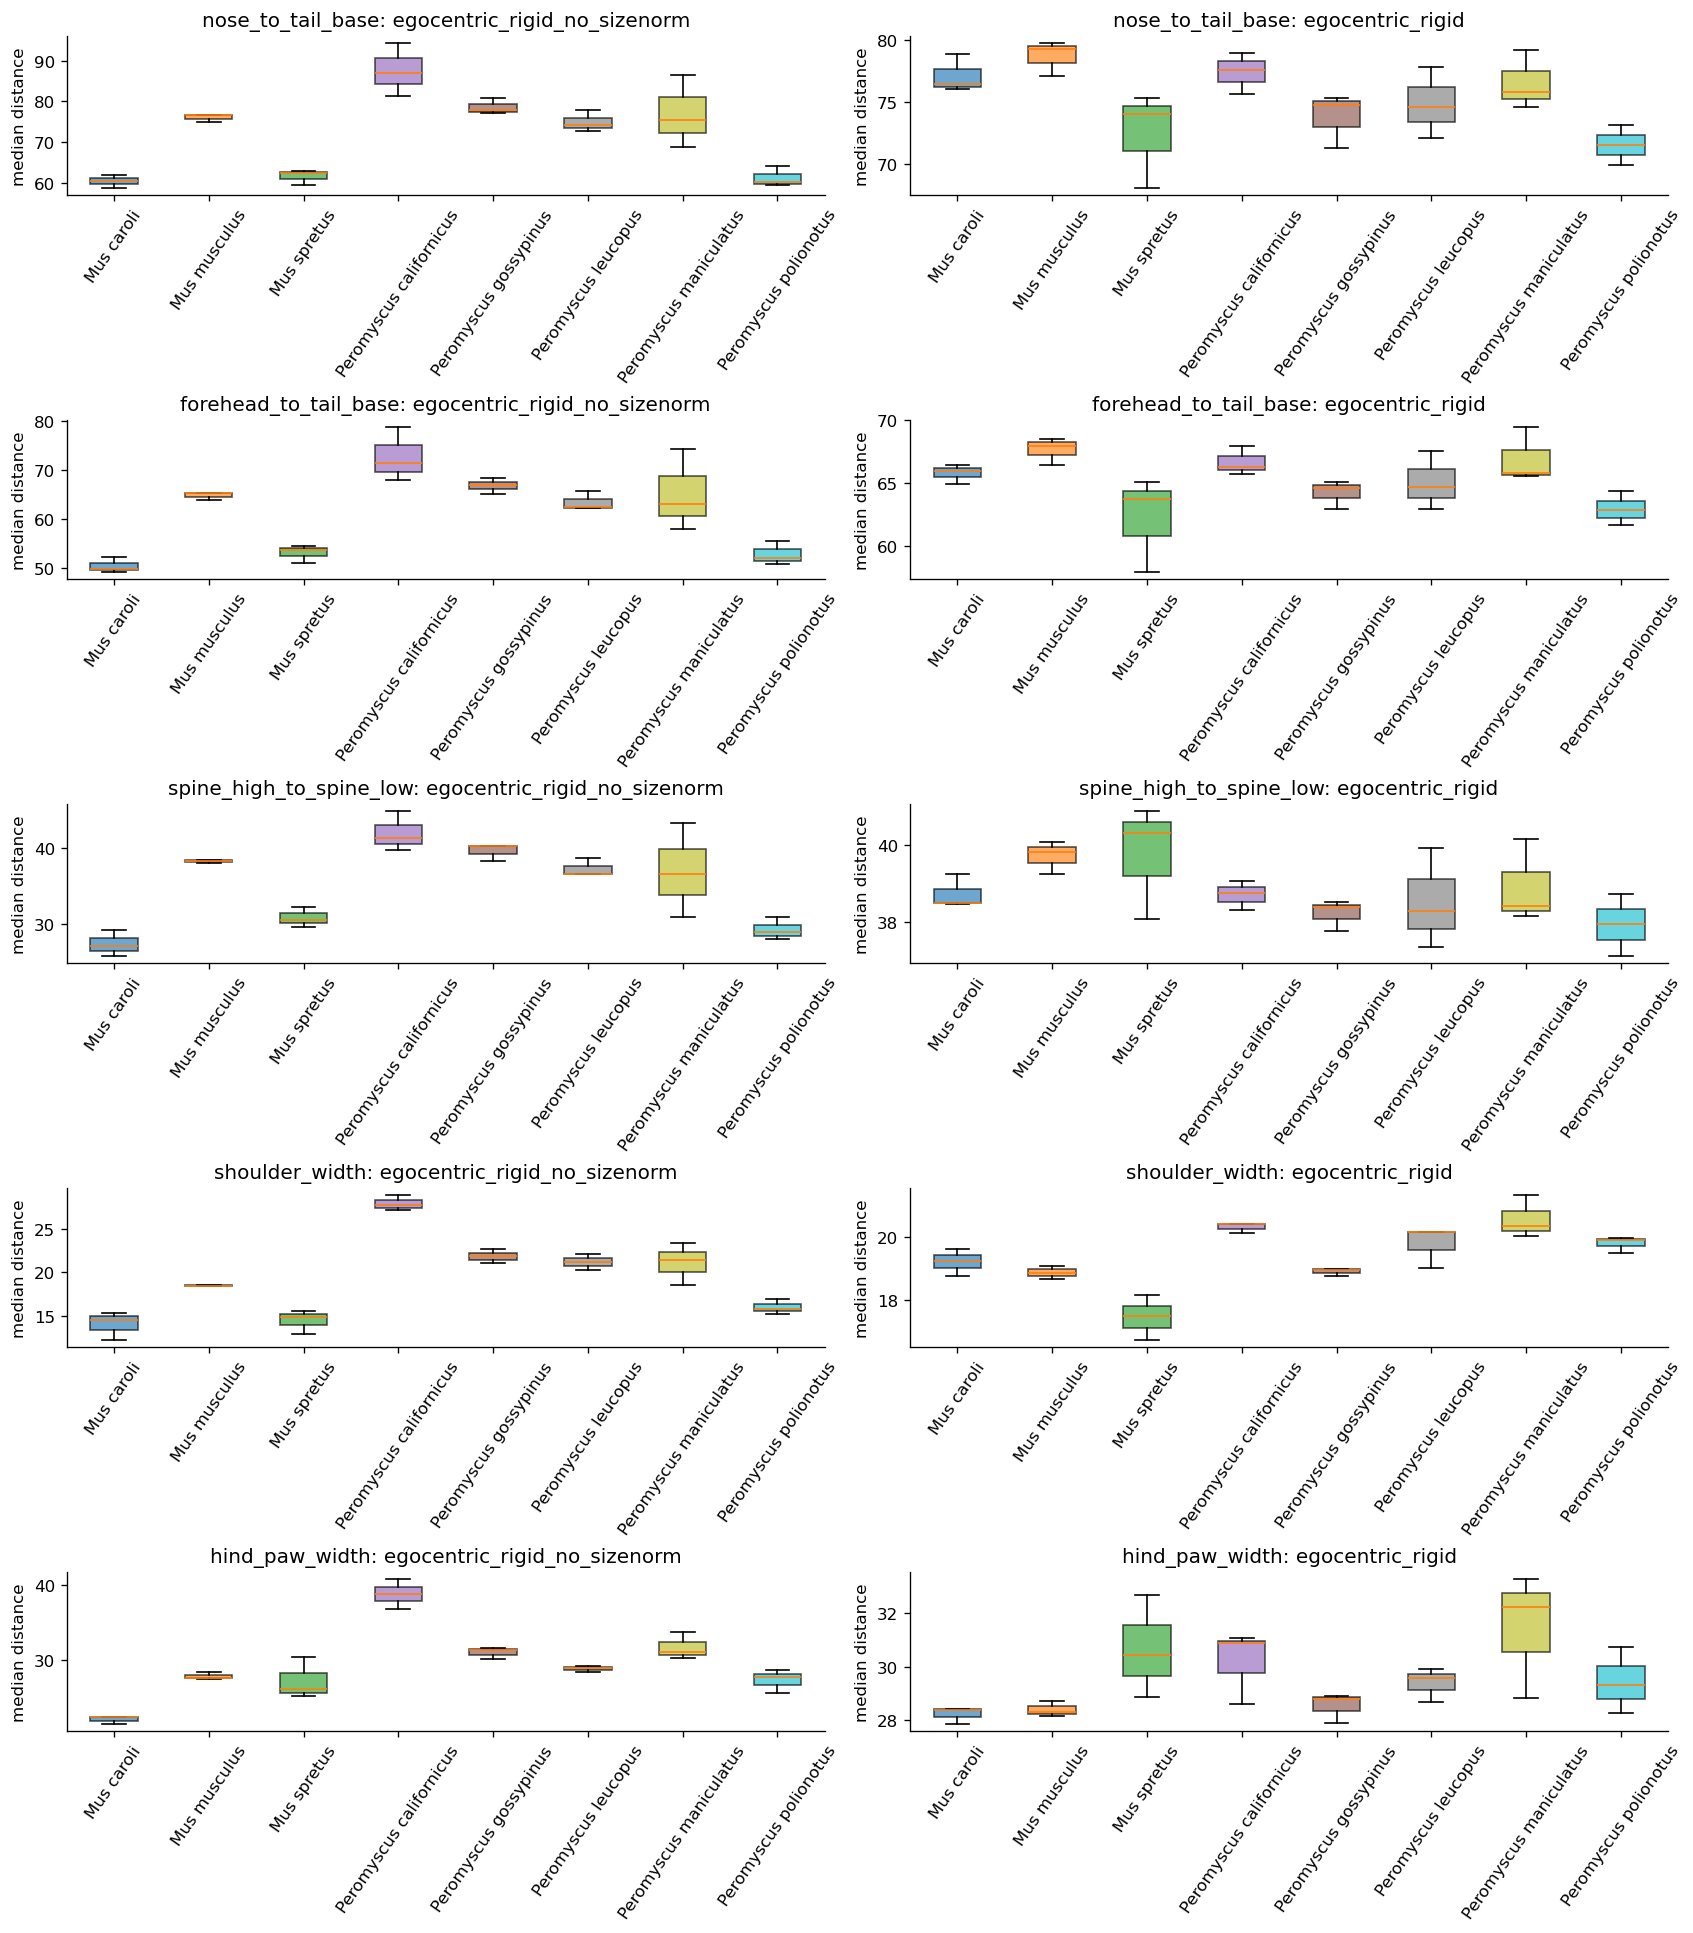

In [6]:
# Plot normalized versus non-normalized skeletal distances by species.
plot_metrics = list(SKELETAL_PAIRS)
fig, axes = plt.subplots(len(plot_metrics), 2, figsize=(14, 3.2 * len(plot_metrics)), constrained_layout=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(species)))

for row_index, metric_name in enumerate(plot_metrics):
    for col_index, representation in enumerate(['egocentric_rigid_no_sizenorm', 'egocentric_rigid']):
        ax = axes[row_index, col_index]
        subset = metric_df[(metric_df['metric'] == metric_name) & (metric_df['representation'] == representation)]
        data = [subset.loc[subset['species'].eq(name), 'median_distance'].dropna().to_numpy() for name in species]
        box = ax.boxplot(data, tick_labels=[name.replace('_', ' ') for name in species], showfliers=False, patch_artist=True)
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.65)
        ax.tick_params(axis='x', rotation=55)
        ax.set_ylabel('median distance')
        ax.set_title(f'{metric_name}: {representation}')

savefig(fig, 'normalized_vs_unnormalized_skeletal_distances')


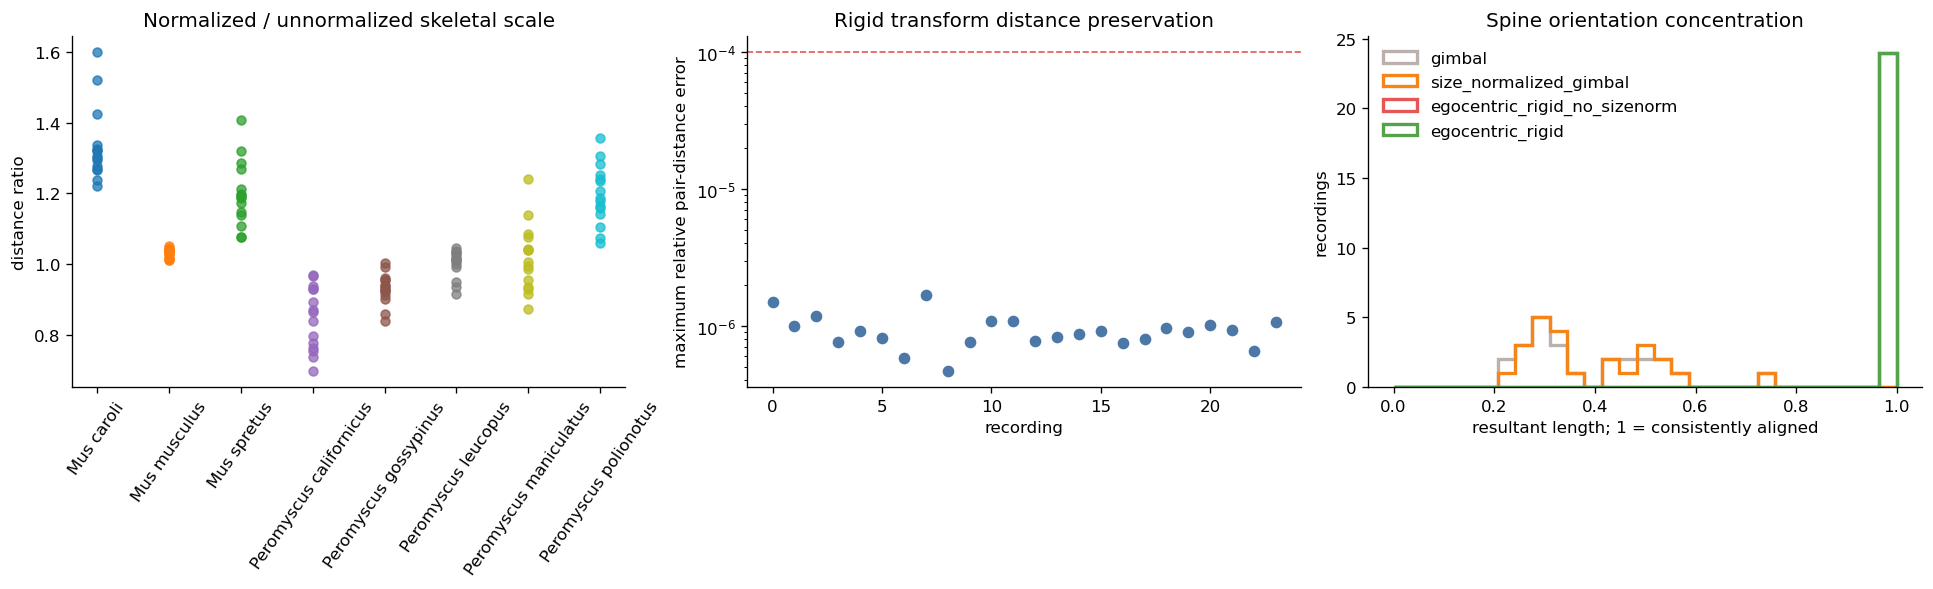

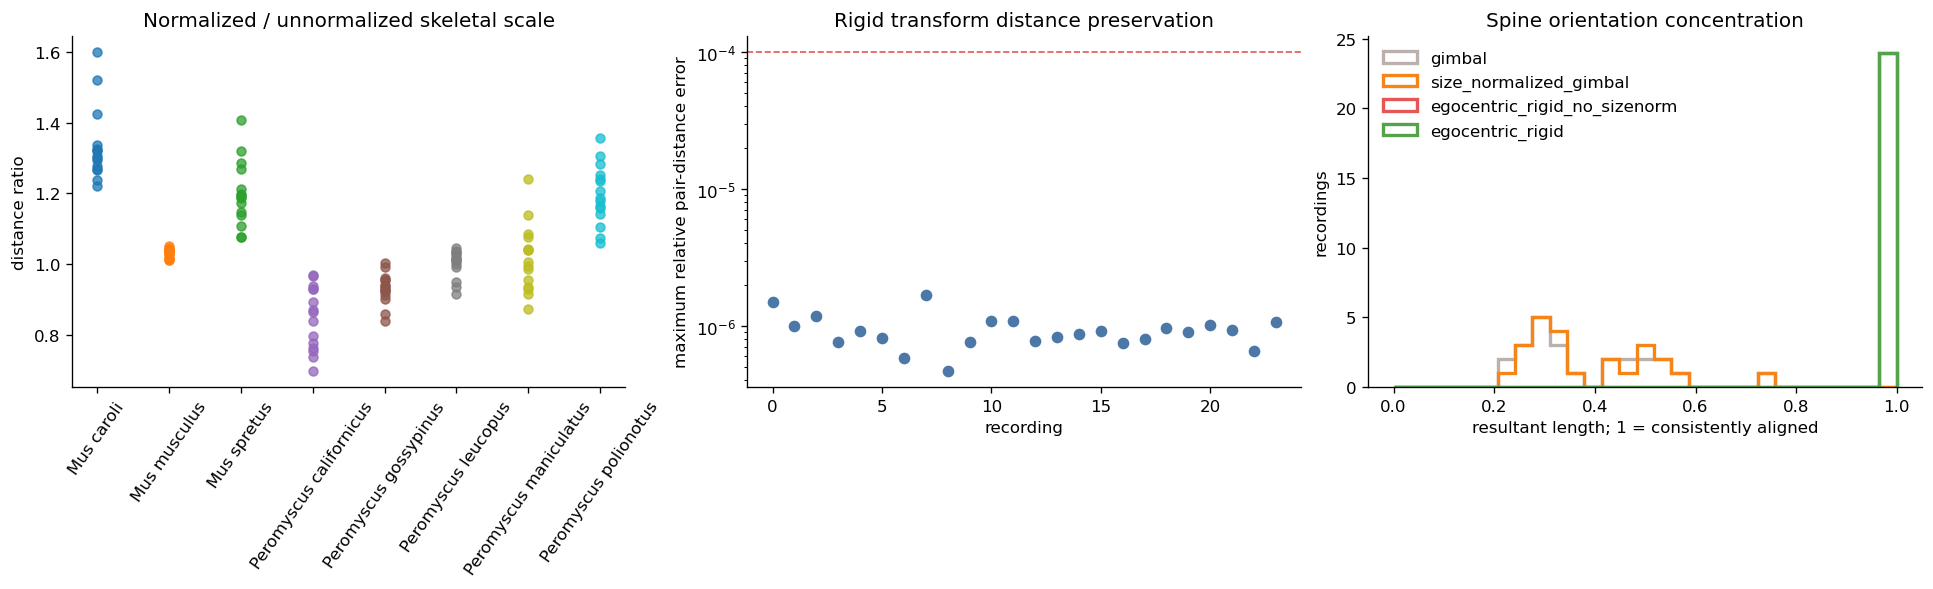

In [7]:
# Plot scale ratios, rigid-distance preservation, and orientation concentration.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for color, species_name in zip(colors, species):
    values = recording_metrics.loc[recording_metrics['species'].eq(species_name), 'normalization_scale_ratio']
    axes[0].scatter(np.repeat(species_name.replace('_', ' '), len(values)), values, color=color, alpha=0.75, s=28)
axes[0].set_title('Normalized / unnormalized skeletal scale')
axes[0].set_ylabel('distance ratio')
axes[0].tick_params(axis='x', rotation=55)

axes[1].semilogy(np.arange(len(invariance_df)), invariance_df['max_relative_distance_error'], 'o', color='#4C78A8')
axes[1].axhline(1e-4, color='#E45756', linestyle='--', linewidth=1)
axes[1].set_title('Rigid transform distance preservation')
axes[1].set_xlabel('recording')
axes[1].set_ylabel('maximum relative pair-distance error')

orientation_plot = orientation_df.pivot_table(
    index=['species', 'subject', 'recording_id'], columns='representation', values='orientation_concentration'
).reset_index()
for representation, color in zip(
    ['gimbal', 'size_normalized_gimbal', 'egocentric_rigid_no_sizenorm', 'egocentric_rigid'],
    ['#BAB0AC', '#F58518', '#E45756', '#54A24B'],
):
    axes[2].hist(orientation_plot[representation].dropna(), bins=np.linspace(0, 1, 30), histtype='step', linewidth=2, label=representation, color=color)
axes[2].set_title('Spine orientation concentration')
axes[2].set_xlabel('resultant length; 1 = consistently aligned')
axes[2].set_ylabel('recordings')
axes[2].legend(frameon=False)

savefig(fig, 'normalization_and_egocentric_validation')


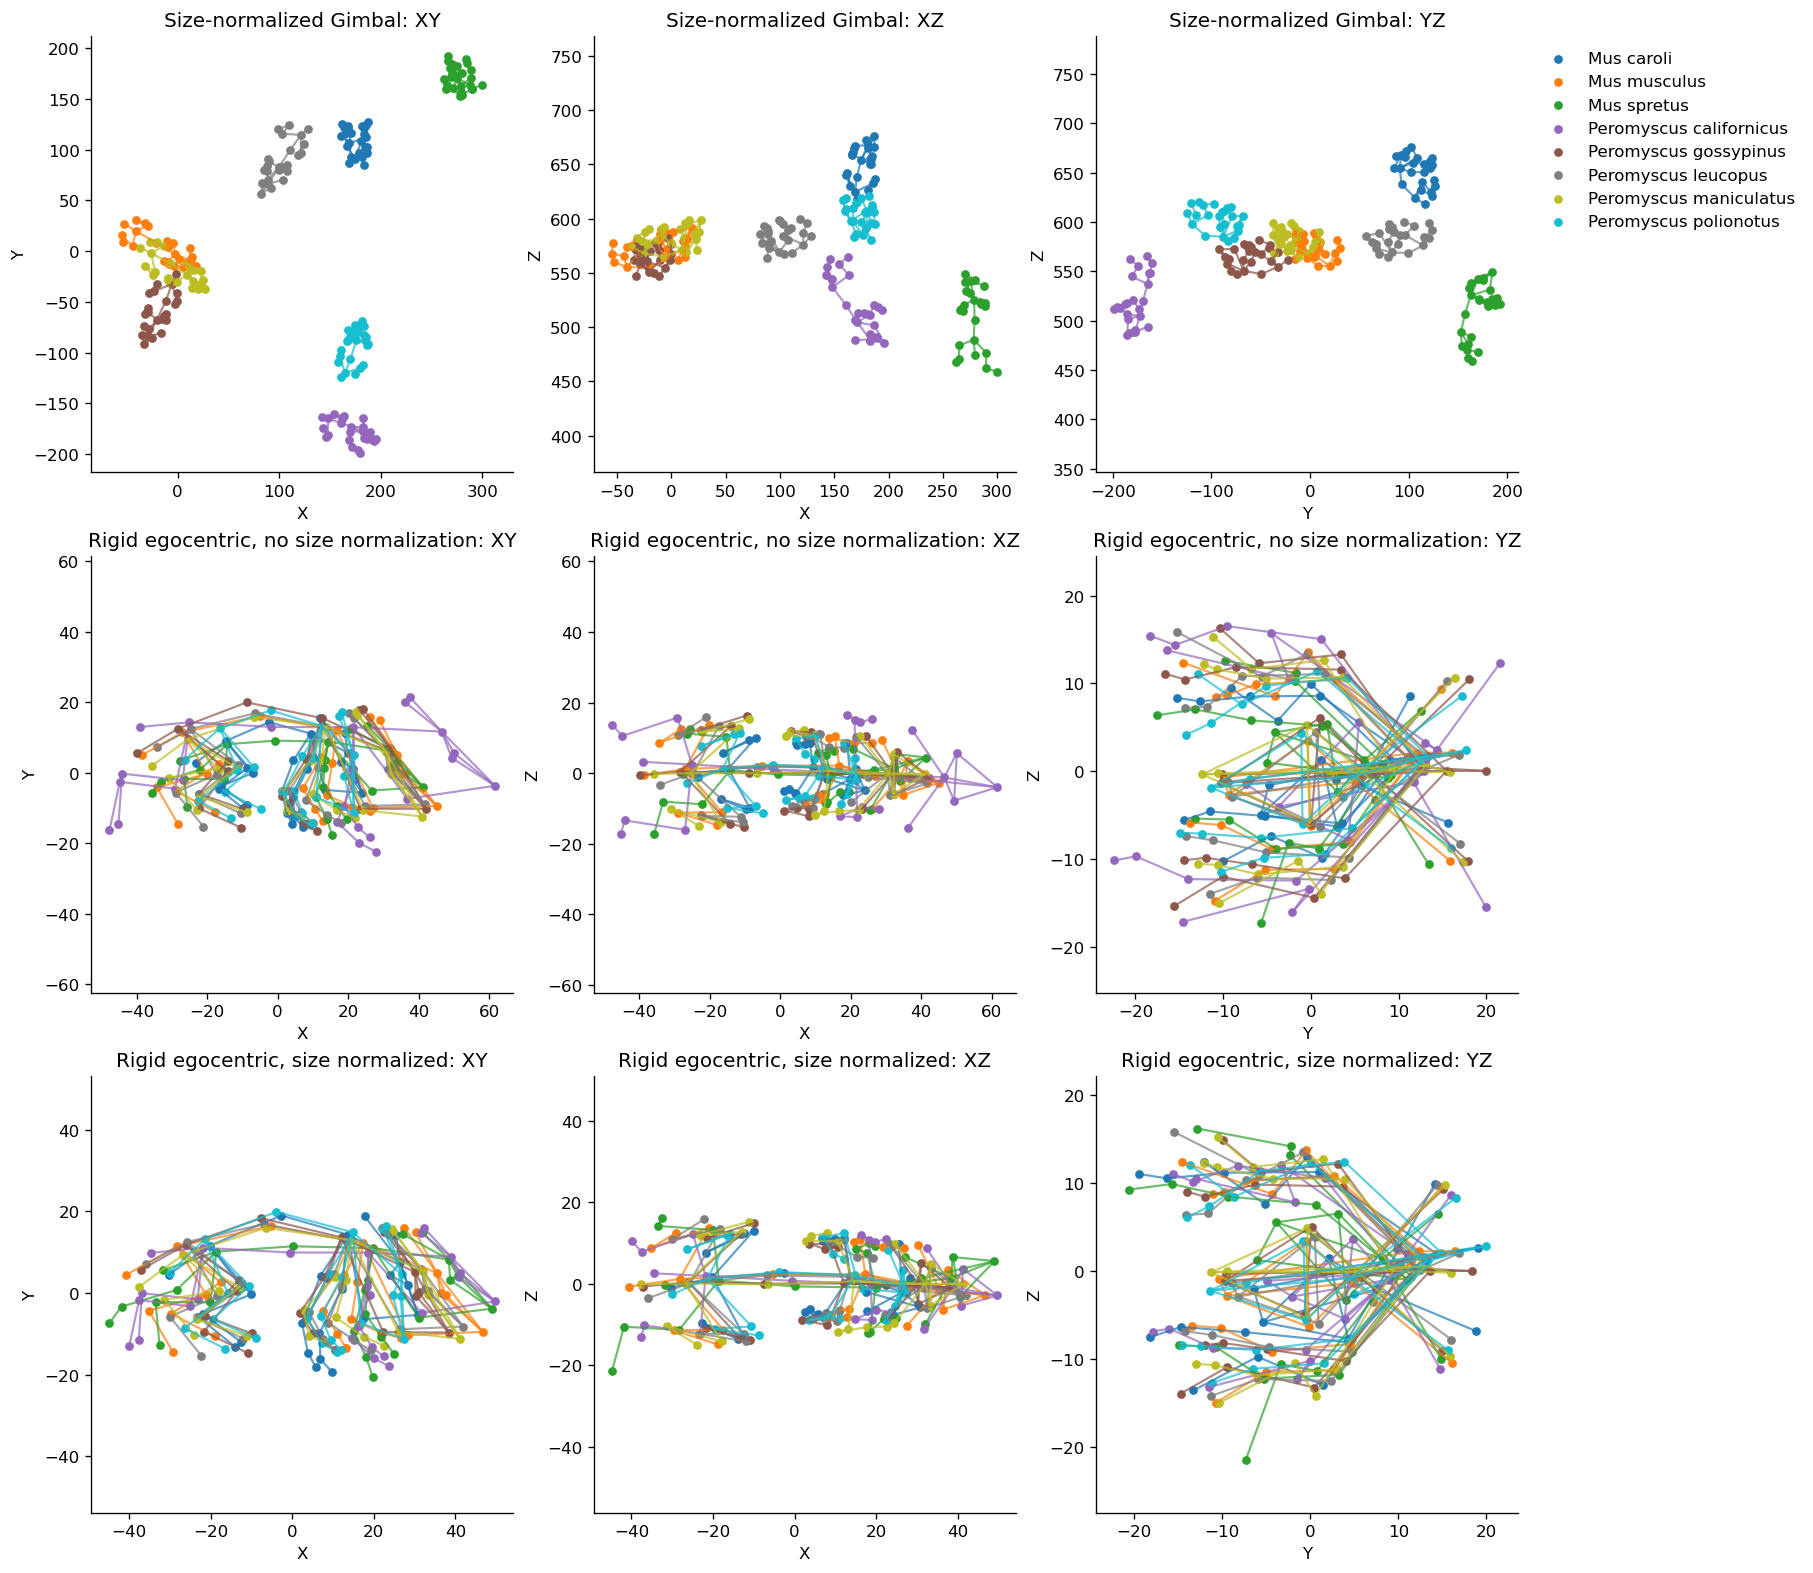

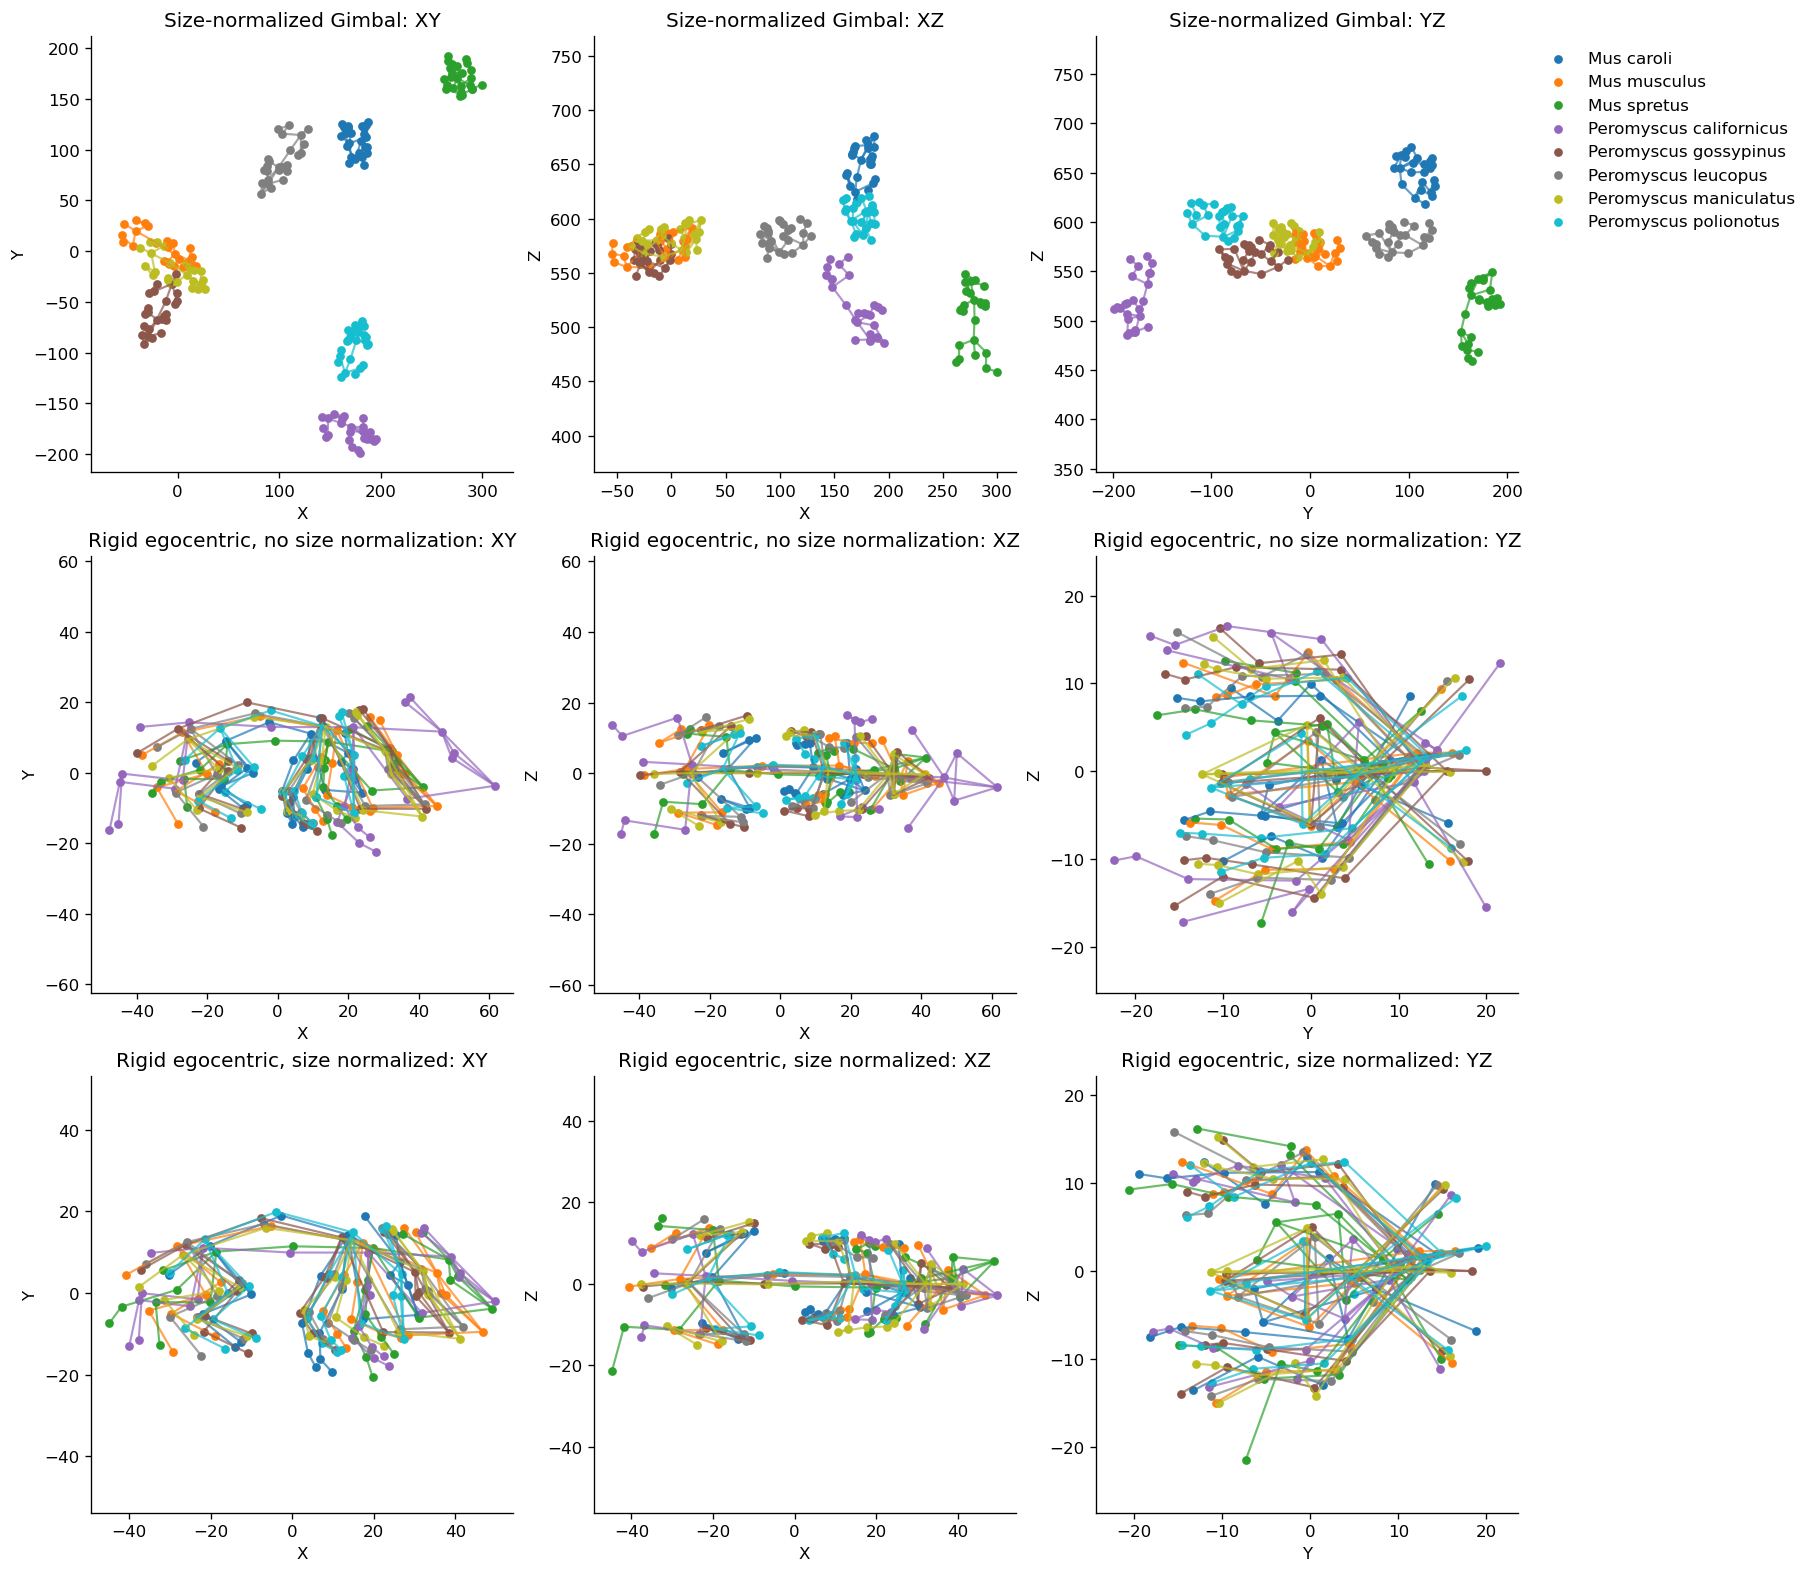

In [8]:
# Show one matched frame per species for normalized and non-normalized source variants.
def plot_skeleton(ax, pose, dims, color, label=None):
    for left_name, right_name in metadata['skeleton']:
        left = bodypart_index[left_name]
        right = bodypart_index[right_name]
        segment = pose[[left, right]][:, dims]
        if np.isfinite(segment).all():
            ax.plot(segment[:, 0], segment[:, 1], color=color, alpha=0.7, linewidth=1.3)
    valid = np.isfinite(pose[:, dims]).all(axis=1)
    ax.scatter(pose[valid, dims[0]], pose[valid, dims[1]], color=color, s=18, label=label)

representative = []
for species_name in species:
    row = selected_manifest[selected_manifest['species_folder'].eq(species_name)].iloc[0]
    path = source_path(row)
    with h5py.File(path, 'r') as f:
        stop = min(MAX_FRAMES_PER_RECORDING, f[DATASETS['confidence']].shape[0])
        frame_index = np.arange(0, stop, FRAME_STRIDE, dtype=int)
        confidence = np.asarray(f[DATASETS['confidence']][frame_index], dtype=float)
        best = int(frame_index[np.argmax(np.sum(confidence >= MIN_CONFIDENCE, axis=1))])
        representative.append({
            'species': species_name,
            'size_normalized_gimbal': np.asarray(f[DATASETS['size_normalized_gimbal']][best], dtype=float),
            'egocentric_rigid_no_sizenorm': np.asarray(f[DATASETS['egocentric_rigid_no_sizenorm']][best], dtype=float),
            'egocentric_rigid': np.asarray(f[DATASETS['egocentric_rigid']][best], dtype=float),
        })

representations = [
    ('size_normalized_gimbal', 'Size-normalized Gimbal'),
    ('egocentric_rigid_no_sizenorm', 'Rigid egocentric, no size normalization'),
    ('egocentric_rigid', 'Rigid egocentric, size normalized'),
]
fig, axes = plt.subplots(len(representations), 3, figsize=(15, 13), constrained_layout=True)
views = [((0, 1), 'XY'), ((0, 2), 'XZ'), ((1, 2), 'YZ')]
for row_index, (representation, representation_label) in enumerate(representations):
    for ax, (dims, title) in zip(axes[row_index], views):
        for result, color in zip(representative, colors):
            plot_skeleton(ax, result[representation], dims, color, result['species'].replace('_', ' '))
        ax.set_title(f'{representation_label}: {title}')
        ax.set_xlabel('XYZ'[dims[0]])
        ax.set_ylabel('XYZ'[dims[1]])
        ax.set_aspect('equal', adjustable='datalim')
axes[0, -1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
savefig(fig, 'matched_normalized_and_non_normalized_keypoint_poses')
